# CBED Exit Wave Comparison: Silicon [111]

Five propagation algorithms compared on Si [111] zone axis (200 keV)
with frozen phonon averaging to produce CBED patterns:
**Fresnel MS**, **Angular Spectrum MS**, **WPM**, **KG ODE**, **KG FWD Lanczos**.

Crystal setup follows `CBED_Si_111.ipynb`: Si.cif → [111] rotation →
orthogonalisation.  A 6.2 mrad convergent probe is propagated through
thermally-displaced potential configurations and diffraction intensities
are averaged to produce the CBED pattern for each method.

In [1]:
%matplotlib widget

import os
from time import perf_counter
import functools

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import ase.io
from matplotlib.colors import LogNorm
from tqdm.auto import tqdm

from wide_angle_propagation.wpm import (
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_kg_ode_full,
)
from wide_angle_propagation.klein_gordon import _lanczos_expsqrt

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

## Crystal, probe, and potential

Si [111] zone axis built from `Si.cif` following the same rotation and
orthogonalisation as `CBED_Si_111.ipynb`.  CBED probe at 6.2 mrad
convergence semi-angle, 200 keV.  Frozen phonon averaging with
$\sigma_\mathrm{Si} = 0.078$ Å.

In [2]:
# --- Parameters ---
energy = 200e3              # 200 keV
n_cells_xy = (6, 4)        # lateral repetitions
n_cells_z = 120            # unit cells along beam
n_slices_per_cell = 6       # uniform slices per [111] cell
n_fp = 1                    # frozen phonon configurations
sigma_Si = 0.078            # RMS thermal displacement (Å)
semiangle_mrad = 6.2        # CBED convergence semi-angle (mrad)

# --- Build Si [111] orthogonal cell (same as CBED_Si_111.ipynb) ---
silicon = ase.io.read("Si.cif")
silicon_111 = silicon.copy()
silicon_111.rotate((0, 0, 1), (1, 1, 1), rotate_cell=True)
silicon_111.rotate(45, "z", rotate_cell=True)
unit_cell = abtem.orthogonalize_cell(silicon_111)

supercell = unit_cell * (*n_cells_xy, n_cells_z)

cell_thickness = float(unit_cell.cell[2, 2])
slice_dz = cell_thickness / n_slices_per_cell
total_thickness = n_cells_z * cell_thickness
n_total_slices = n_cells_z * n_slices_per_cell

# --- Reference potential (undisplaced, for grid matching + timing) ---
potential_ref = abtem.Potential(
    supercell, sampling=0.1, slice_thickness=slice_dz,
    projection="finite", parametrization="lobato",
)
gpts = tuple(potential_ref.gpts)

# --- CBED probe ---
probe = abtem.Probe(energy=energy, semiangle_cutoff=semiangle_mrad)
probe.grid.match(potential_ref)
probe_array = jnp.array(cupy.asnumpy(probe.build(lazy=False).array))
sampling = (float(probe.grid.sampling[0]), float(probe.grid.sampling[1]))

# --- Propagation kernels (same for all frozen phonon configs) ---
fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))

wavelength = energy2wavelength(energy)
print(f"Crystal: Si [111] (orthogonalised from Si.cif)")
print(f"Supercell: {n_cells_xy[0]}×{n_cells_xy[1]}×{n_cells_z}, {len(supercell)} atoms")
lx, ly, lz = supercell.cell.lengths()
print(f"Cell: {lx:.1f} × {ly:.1f} × {lz:.1f} Å")
print(f"Energy: {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"Slices: {n_total_slices} total ({n_slices_per_cell}/cell), dz = {slice_dz:.4f} Å")
print(f"Total thickness: {total_thickness:.1f} Å")
print(f"CBED probe: {semiangle_mrad} mrad semi-angle")
print(f"Frozen phonons: {n_fp} configs, σ = {sigma_Si} Å")

Crystal: Si [111] (orthogonalised from Si.cif)
Supercell: 6×4×120, 138240 atoms
Cell: 46.2 × 53.3 × 1131.5 Å
Energy: 200 keV, λ = 0.0251 Å
Grid: (462, 534), sampling = (0.1000, 0.0999) Å
Slices: 720 total (6/cell), dz = 1.5715 Å
Total thickness: 1131.5 Å
CBED probe: 6.2 mrad semi-angle
Frozen phonons: 1 configs, σ = 0.078 Å


## KG Forward Lanczos propagator

Applies $\exp(i \, dz \, \sqrt{M})$ per slice via FFT-based matvec + Lanczos
iteration.  Scans through the **full** potential stack (all slices) in one call.

In [ ]:
def simulate_kg_fwd_lanczos(pot_arr, psi_0, dz, E, samp, lanczos_m=130):
    """Propagate through full potential stack via KG FWD Lanczos (all beams).

    Uses a jitted per-slice loop instead of lax.scan to avoid tracing
    the full slice stack at compile time.
    """
    ny, nx = psi_0.shape
    k0_sq = (2 * jnp.pi / energy2wavelength(E)) ** 2

    dy, dx = samp
    fy = jnp.fft.fftfreq(ny, d=dy)
    fx = jnp.fft.fftfreq(nx, d=dx)
    Fx, Fy = jnp.meshgrid(fx, fy)
    kp_sq = (2 * jnp.pi * Fy) ** 2 + (2 * jnp.pi * Fx) ** 2

    n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, E) ** 2)(pot_arr)

    probe_k = jnp.fft.fft2(jnp.asarray(psi_0, dtype=jnp.complex128)) / (ny * nx)
    state = probe_k.ravel()

    @functools.partial(jax.jit, static_argnums=(4, 5, 6))
    def _propagate_one_slice(s, n_sq, k0sq, kpsq, ny_, nx_, m_):
        def matvec(v):
            vg = v.reshape(ny_, nx_)
            conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
            return (k0sq * conv - kpsq * vg).ravel()
        return _lanczos_expsqrt(matvec, s, dz, m_)

    for i in range(pot_arr.shape[0]):
        state = _propagate_one_slice(state, n_sq_all[i], k0_sq, kp_sq, ny, nx, lanczos_m)

    exit_k = state.reshape(ny, nx)
    exit_wave = jnp.fft.ifft2(exit_k) * (ny * nx)
    return np.asarray(exit_wave)

: 

In [ ]:
# --- Frozen phonon propagation ---
method_names = ["Fresnel MS", "Angular Spectrum", "WPM", "KG ODE", "KG FWD Lanczos"]
dp_avg = {name: np.zeros(gpts) for name in method_names}
exit_waves = {}

rng = np.random.default_rng(42)

for fp_idx in tqdm(range(n_fp), desc="Frozen phonon configs"):
    # Displace atoms thermally
    displaced = supercell.copy()
    displaced.positions += rng.normal(0, sigma_Si, displaced.positions.shape)
    displaced.wrap()
    displaced.info["thermal_sigma"] = 0.0
    displaced.arrays["thermal_sigma"] = np.zeros(len(displaced))

    # Build potential for this configuration
    pot_fp = abtem.Potential(
        displaced, gpts=gpts, slice_thickness=slice_dz,
        projection="finite", parametrization="lobato",
    )
    pot_arr = jnp.array(cupy.asnumpy(pot_fp.build(lazy=False).array / slice_dz))

    # Run 5 methods
    ew_f, _, _ = simulate_fresnel_as(pot_arr, probe_array, fk, slice_dz, energy)
    ew_a, _, _ = simulate_fresnel_as(pot_arr, probe_array, ak, slice_dz, energy)
    ew_w, _, _ = simulate_wpm(pot_arr, probe_array, slice_dz, energy, sampling)
    ew_o, _, _, _ = simulate_kg_ode_full(pot_arr, probe_array, slice_dz, energy, sampling,
                                          rtol=1e-5, atol=1e-7)
    ew_l = simulate_kg_fwd_lanczos(pot_arr, probe_array, slice_dz, energy, sampling)

    # Accumulate |DP|²
    for name, ew in zip(method_names, [ew_f, ew_a, ew_w, ew_o, ew_l]):
        dp_i = np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(ew)))) ** 2
        dp_avg[name] += dp_i / n_fp

    # Keep last configuration exit waves for later comparison
    if fp_idx == n_fp - 1:
        exit_waves = dict(zip(
            method_names,
            [np.asarray(e) for e in [ew_f, ew_a, ew_w, ew_o, ew_l]],
        ))

    print(f"  Config {fp_idx + 1}/{n_fp} done.")

print(f"\nFrozen phonon averaging complete ({n_fp} configs × {len(method_names)} methods).")

Frozen phonon configs:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Quick summary
for name in method_names:
    ew = exit_waves[name]
    dp = dp_avg[name]
    print(f"{name:22s}  |exit| range [{np.abs(ew).min():.6f}, {np.abs(ew).max():.6f}]"
          f"   DP max {dp.max():.4e}")

Fresnel MS              |exit| range [0.000000, 0.000147]   DP max 1.3305e-03
Angular Spectrum        |exit| range [0.000000, 0.000147]   DP max 1.3298e-03
WPM                     |exit| range [0.000000, 0.000144]   DP max 1.3299e-03
KG FWD Lanczos          |exit| range [0.000000, 0.000148]   DP max 1.3504e-03


## CBED patterns (frozen phonon averaged)

Diffraction intensities averaged over all frozen phonon configurations.
Displayed on a log scale.

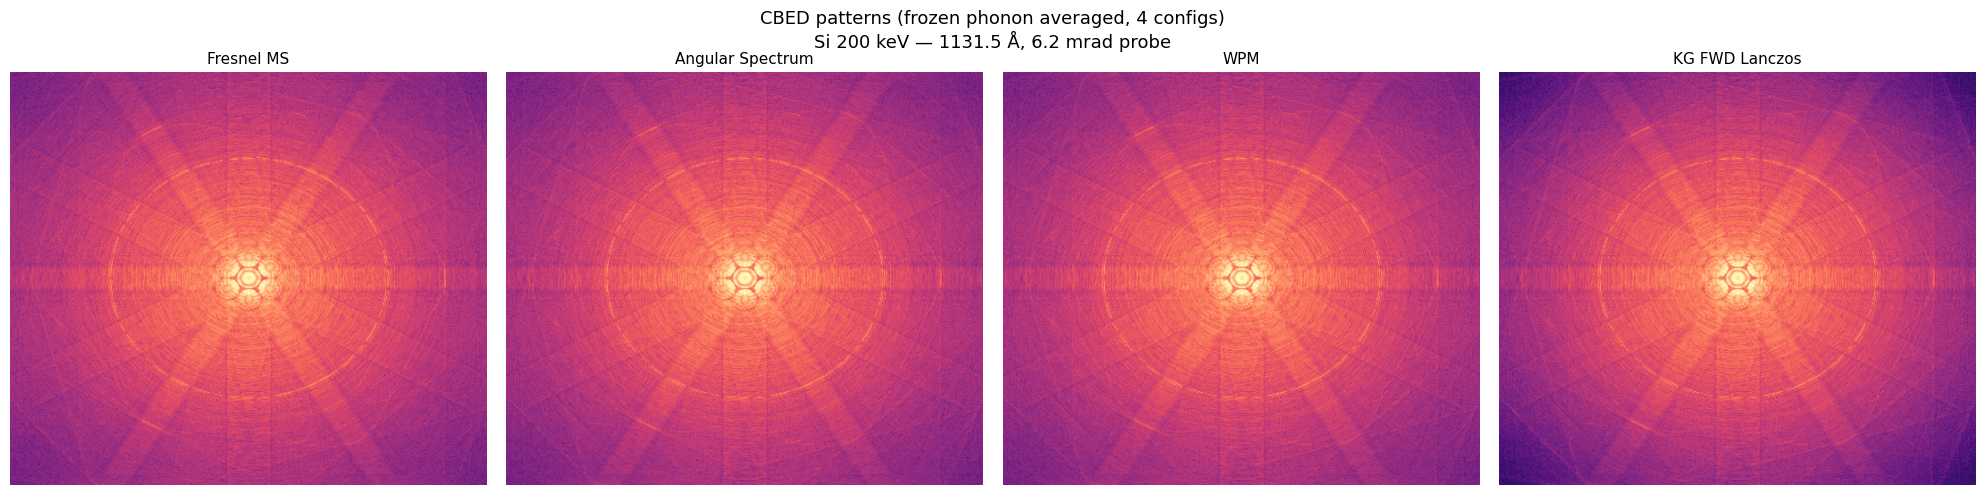

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for j, name in enumerate(method_names):
    dp = dp_avg[name]
    dp_n = dp / dp.max() if dp.max() > 0 else dp
    axes[j].imshow(dp_n, norm=LogNorm(vmin=1e-8, vmax=1), cmap="magma", origin="lower")
    axes[j].set_title(name, fontsize=11)
    axes[j].axis("off")

fig.suptitle(
    f"CBED patterns (frozen phonon averaged, {n_fp} configs)\n"
    f"Si {energy/1e3:.0f} keV — {total_thickness:.1f} Å, {semiangle_mrad} mrad probe",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Exit wave comparison (last frozen phonon configuration)

Top row: amplitude.  Bottom row: phase.  All methods on shared colour scales.

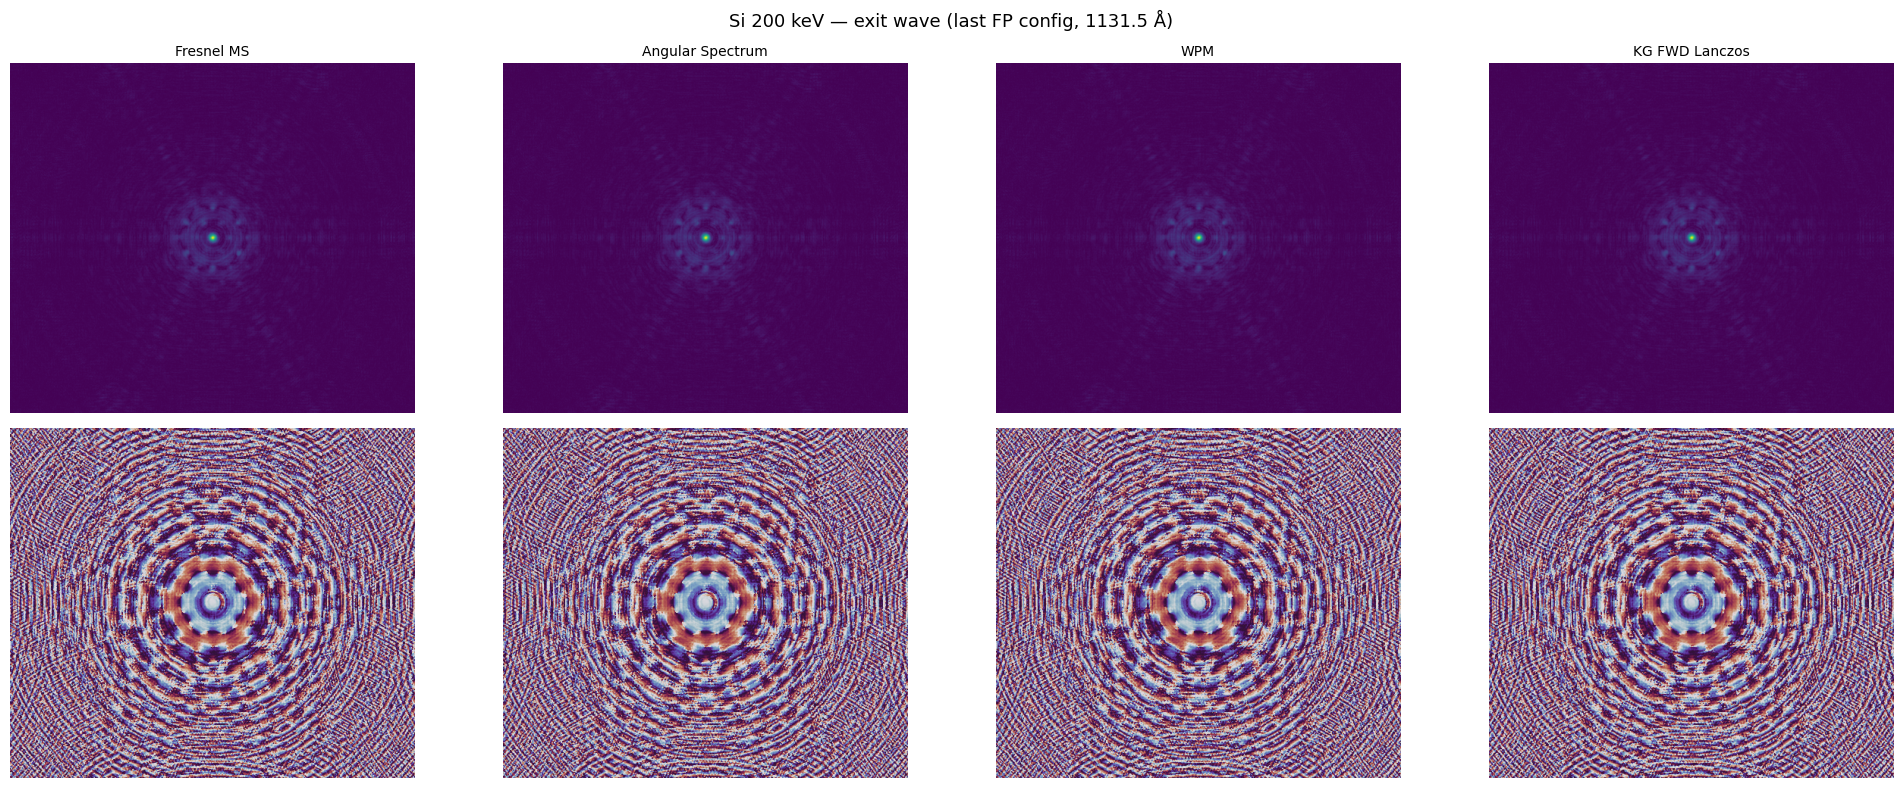

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(24, 8))

all_amps = [np.abs(exit_waves[n]) for n in method_names]
vmin_a = min(a.min() for a in all_amps)
vmax_a = max(a.max() for a in all_amps)

for j, name in enumerate(method_names):
    ew = exit_waves[name]
    im_a = axes[0, j].imshow(np.abs(ew), cmap="viridis", vmin=vmin_a, vmax=vmax_a, origin="lower")
    axes[0, j].set_title(name, fontsize=10)
    axes[0, j].axis("off")

    im_p = axes[1, j].imshow(np.angle(ew), cmap="twilight", vmin=-np.pi, vmax=np.pi, origin="lower")
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Amplitude", fontsize=12)
axes[1, 0].set_ylabel("Phase", fontsize=12)

fig.suptitle(f"Si {energy/1e3:.0f} keV — exit wave (last FP config, {total_thickness:.1f} Å)", fontsize=13)
plt.tight_layout()
plt.show()

## Error analysis

All differences computed relative to Angular Spectrum multislice.

Reference: Angular Spectrum

Method                   Amp RMSE    Amp Max    Ph RMSE     Ph Max     Rel L2
-----------------------------------------------------------------------------
Fresnel MS               6.91e-07   4.15e-06     39.70°    180.00°   2.70e-01
Angular Spectrum         0.00e+00   0.00e+00      0.00°      0.00°   0.00e+00
WPM                      8.71e-07   8.55e-06     50.99°    180.00°   3.95e-01
KG FWD Lanczos           4.91e-07   3.49e-06     30.84°    179.97°   2.32e-01


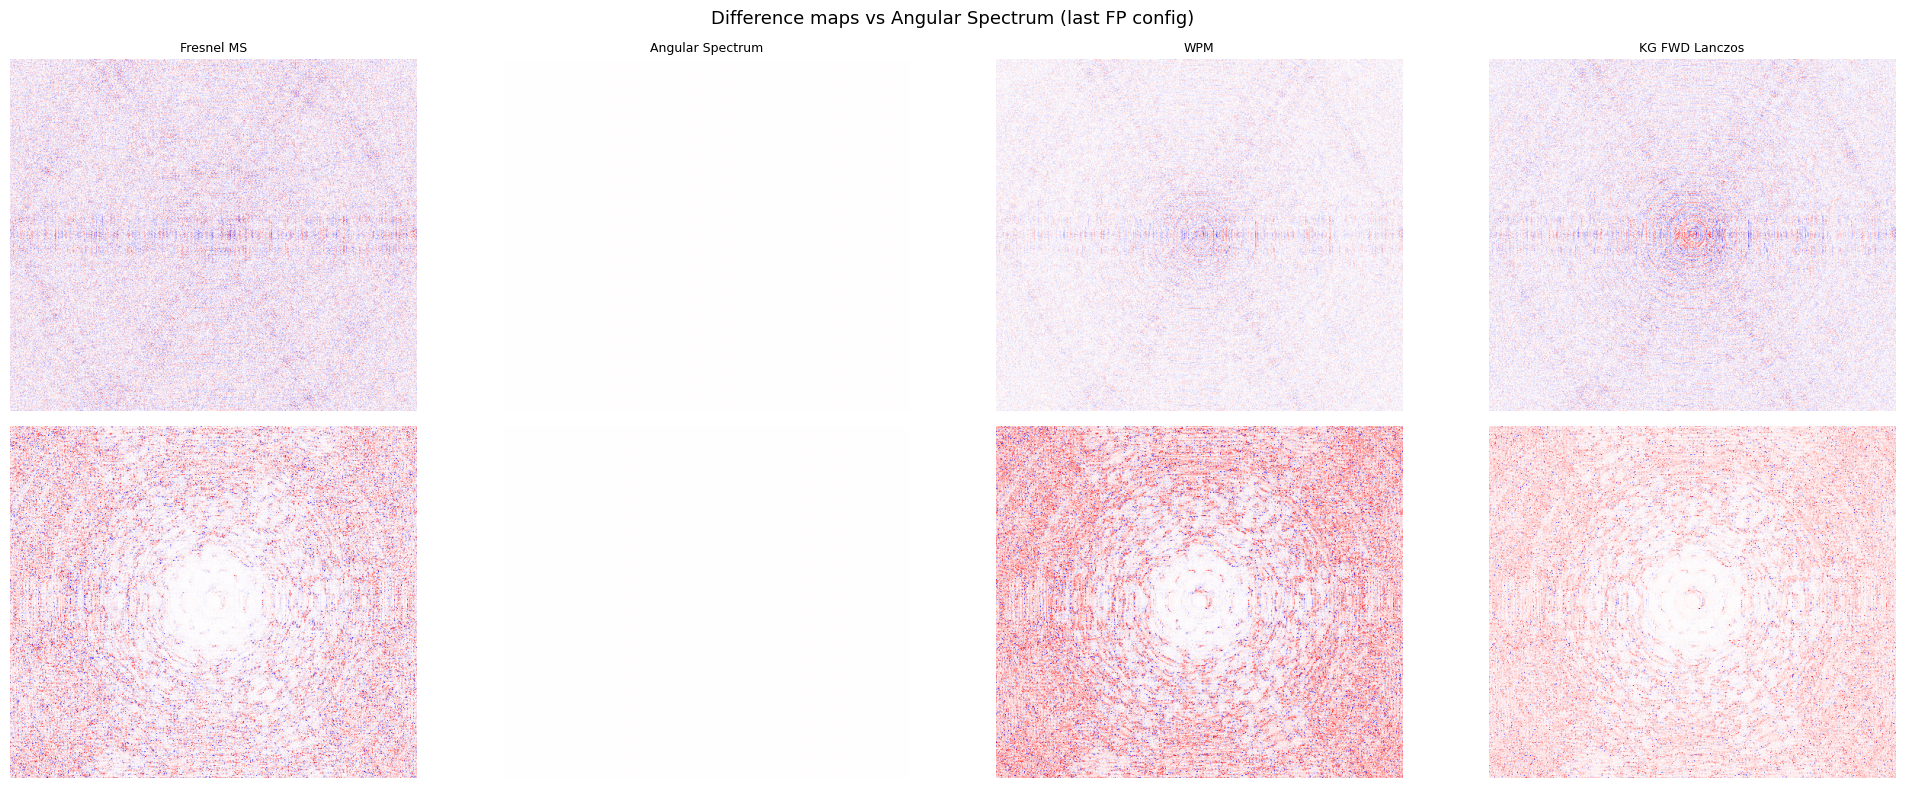

In [ ]:
ref_label = "Angular Spectrum"
ref = exit_waves[ref_label]

def wrap_phase_diff(a, b):
    return (a - b + np.pi) % (2 * np.pi) - np.pi

def metrics(ew, ref):
    ad = np.abs(ew) - np.abs(ref)
    pd = wrap_phase_diff(np.angle(ew), np.angle(ref))
    cd = ew - ref
    return {
        "amp_rmse": float(np.sqrt(np.mean(ad**2))),
        "amp_max": float(np.max(np.abs(ad))),
        "ph_rmse": float(np.degrees(np.sqrt(np.mean(pd**2)))),
        "ph_max": float(np.degrees(np.max(np.abs(pd)))),
        "rel_l2": float(np.linalg.norm(cd) / np.linalg.norm(ref)),
    }

hdr = f"{'Method':<22s} {'Amp RMSE':>10s} {'Amp Max':>10s} {'Ph RMSE':>10s} {'Ph Max':>10s} {'Rel L2':>10s}"
print(f"Reference: {ref_label}\n")
print(hdr)
print("-" * len(hdr))
for name in method_names:
    ew = exit_waves[name]
    m = metrics(ew, ref)
    print(f"{name:<22s} {m['amp_rmse']:>10.2e} {m['amp_max']:>10.2e} "
          f"{m['ph_rmse']:>9.2f}\u00b0 {m['ph_max']:>9.2f}\u00b0 {m['rel_l2']:>10.2e}")

# --- Difference maps ---
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
for j, name in enumerate(method_names):
    ew = exit_waves[name]
    ad = np.abs(ew) - np.abs(ref)
    pd = wrap_phase_diff(np.angle(ew), np.angle(ref))

    va = np.max(np.abs(ad)) or 1e-10
    axes[0, j].imshow(ad, cmap="bwr", vmin=-va, vmax=va, origin="lower")
    axes[0, j].set_title(name, fontsize=9)
    axes[0, j].axis("off")

    vp = np.max(np.abs(pd)) or 1e-10
    axes[1, j].imshow(pd, cmap="bwr", vmin=-vp, vmax=vp, origin="lower")
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("\u0394 Amplitude", fontsize=11)
axes[1, 0].set_ylabel("\u0394 Phase", fontsize=11)
fig.suptitle(f"Difference maps vs {ref_label} (last FP config)", fontsize=13)
plt.tight_layout()
plt.show()

## Timing benchmark

Each method is timed independently over the full propagation.

In [ ]:
# Time each method on the undisplaced reference potential
pot_ref = jnp.array(cupy.asnumpy(potential_ref.build(lazy=False).array / slice_dz))

timings = {}

# 1. Fresnel MS
t0 = perf_counter()
_ = simulate_fresnel_as(pot_ref, probe_array, fk, slice_dz, energy)
_ = np.asarray(_[0])
timings["Fresnel MS"] = perf_counter() - t0

# 2. Angular Spectrum MS
t0 = perf_counter()
_ = simulate_fresnel_as(pot_ref, probe_array, ak, slice_dz, energy)
_ = np.asarray(_[0])
timings["Angular Spectrum"] = perf_counter() - t0

# 3. WPM
t0 = perf_counter()
_ = simulate_wpm(pot_ref, probe_array, slice_dz, energy, sampling)
_ = np.asarray(_[0])
timings["WPM"] = perf_counter() - t0

# 4. KG ODE
t0 = perf_counter()
_ = simulate_kg_ode_full(pot_ref, probe_array, slice_dz, energy, sampling,
                          rtol=1e-5, atol=1e-7)
_ = np.asarray(_[0])
timings["KG ODE"] = perf_counter() - t0

# 5. KG FWD Lanczos
t0 = perf_counter()
_ = simulate_kg_fwd_lanczos(pot_ref, probe_array, slice_dz, energy, sampling)
timings["KG FWD Lanczos"] = perf_counter() - t0

print(f"Timing: {n_total_slices} slices, grid {gpts[0]}×{gpts[1]}\n")
print(f"{'Method':<22s} {'Time (s)':>10s} {'Relative':>10s}")
print("-" * 44)
t_ref = timings["Fresnel MS"]
for name, t in timings.items():
    print(f"{name:<22s} {t:>10.2f} {t/t_ref:>9.1f}×")

Timing: 720 slices, grid 462×534

Method                   Time (s)   Relative
--------------------------------------------
Fresnel MS                   1.16       1.0×
Angular Spectrum             1.41       1.2×
WPM                         17.66      15.2×
KG FWD Lanczos              21.71      18.7×
